In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.sparse import hstack
from sklearn.utils import shuffle
warnings.filterwarnings('ignore')

import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, SnowballStemmer
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

from sklearn.feature_selection import SelectKBest, f_classif, chi2
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from scipy.stats import f_oneway

from sklearn.naive_bayes import MultinomialNB, GaussianNB, ComplementNB

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, normalize

## Dataset for Arabic Classification

### Loading and Exploring Dataset

In [2]:
df2=pd.read_csv("/kaggle/input/datasets/salmahafid/arabic-classification/arabic_dataset_classifiction.csv")
print("colonnes:",df2.columns.tolist())
print(df2.info())

colonnes: ['text', 'targe']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111728 entries, 0 to 111727
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    108789 non-null  object
 1   targe   111728 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.7+ MB
None


In [3]:
print(f'\n Shape: {df2.shape}')
df2.head()


 Shape: (111728, 2)


,text,targe
0,بين أستوديوهات ورزازات وصحراء مرزوكة وآثار ولي...,0
1,قررت النجمة الأمريكية أوبرا وينفري ألا يقتصر ع...,0
2,أخبارنا المغربية الوزاني تصوير الشملالي ألهب ا...,0
3,اخبارنا المغربية قال ابراهيم الراشدي محامي سعد...,0
4,تزال صناعة الجلود في المغرب تتبع الطريقة التقل...,0


In [4]:
print('General Information :')
print(df2.info())
print('\n Class Distribution :')
print(df2['targe'].value_counts())

General Information :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111728 entries, 0 to 111727
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    108789 non-null  object
 1   targe   111728 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.7+ MB
None

 Class Distribution :
targe
4    46522
3    20505
1    16728
2    14235
0    13738
Name: count, dtype: int64


In [5]:
df2= df2.dropna(subset=['text'])
n_per_group = 10000
df_balanced = df2.groupby('targe').sample(n=n_per_group, random_state=42).copy()

df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print(df_balanced['targe'].value_counts())
print(f"\nTaille finale : {df_balanced.shape[0]} lignes")

targe
3    10000
0    10000
1    10000
4    10000
2    10000
Name: count, dtype: int64

Taille finale : 50000 lignes


## Arabic Text Preprocessing

In [6]:
def preprocess_arabic(text):
    if not isinstance(text, str):
        return ''
    text = re.sub(r'[\u0610-\u061A\u064B-\u065F\u0670]', '', text)
    text = re.sub(r'http\S+|www\S+|@\S+', '', text)
    text = re.sub(r'[a-zA-Z0-9]', '', text)
    text = re.sub(r'[!"#$%&\'()*+,-./:;<=>?@[\\\]^_`{|}~]', '', text)
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)
    text = re.sub(r'\s+', ' ', text).strip()
    ar_stopwords = {'في','من','على','إلى','عن','مع','هذا','هذه','التي','الذي',
                    'كان','كانت','لكن','أو','أن','لا','ما','كل','هو','هي','نحن',
                    'أنا','انت','له','لها','به','بها','وقد','قد','ثم','إن','وان'}
    tokens = text.split()
    tokens = [t for t in tokens if t not in ar_stopwords and len(t) > 2]
    return ' '.join(tokens)

df_balanced = df_balanced.dropna(subset=['text', 'targe']).reset_index(drop=True)
df_balanced['text_clean'] = df_balanced['text'].apply(preprocess_arabic)

le2 = LabelEncoder()
df_balanced['label_enc'] = le2.fit_transform(df_balanced['targe'])

df_balanced['text_length'] = df_balanced['text_clean'].apply(lambda x: len(x.split()))
print(f'Average Length (in Words: {df_balanced["text_length"].mean():.1f}')
print(f'Class: {le2.classes_.tolist()}')
df_balanced[['text_clean','label_enc']].head(3)

Average Length (in Words: 228.9
Class: [0, 1, 2, 3, 4]


,text_clean,label_enc
0,اكد وزير الشوون الخارجيه الدنماركي اندرس ساموي...,3
1,كشف الفنان المصري المعروف محمود الجندي انه ابت...,0
2,الحضاره امي عمل يعرض بالمسارح والموسسات التعلي...,0


## TF-IDF Vectorization

In [7]:
X2 = df_balanced['text_clean']
y2 = df_balanced['label_enc']

X2_train_txt, X2_test_txt, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42, stratify=y2
)

N_FEATURES_DS2 = 5000

tfidf2 = TfidfVectorizer(
    max_features=N_FEATURES_DS2,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

X2_train = tfidf2.fit_transform(X2_train_txt)
X2_test  = tfidf2.transform(X2_test_txt)

print(f'TF-IDF Vectorization :')
print(f'Shape train: {X2_train.shape}')
print(f'Shape test:  {X2_test.shape}')

TF-IDF Vectorization :
Shape train: (40000, 5000)
Shape test:  (10000, 5000)


In [8]:
def evaluate_nb(X_train, X_test, y_train, y_test, method_name, dataset_name):
    clf = ComplementNB()
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(clf, X_train, y_train, cv=cv, scoring='accuracy')

    return {
        'Dataset': dataset_name,
        'Method': method_name,
        'Nb Features': X_train.shape[1],
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'CV Mean': round(cv_scores.mean(), 4),
        'CV Std': round(cv_scores.std(), 4),
        'y_pred': y_pred,
        'y_test': y_test
    }


## Naive Bayes Classification — Feature Selection Comparison


In [9]:
K_BEST_DS2 = 1000
results_ds2 = []

# Without Feature Selection
print('Without Feature Selection...')
res = evaluate_nb(X2_train, X2_test, y2_train, y2_test,
                  'Without FS', 'Dataset 2')
results_ds2.append(res)
print(f'   Accuracy: {res["Accuracy"]:.4f} | F1: {res["F1-Score"]:.4f}')

# Fisher Score
print(' Fisher Score (chi2)...')
selector_fisher2 = SelectKBest(chi2, k=K_BEST_DS2)
X2_train_fisher = selector_fisher2.fit_transform(X2_train, y2_train)
X2_test_fisher  = selector_fisher2.transform(X2_test)
res = evaluate_nb(X2_train_fisher, X2_test_fisher, y2_train, y2_test,
                  f'Fisher (chi2, k={K_BEST_DS2})', 'Dataset 2')
results_ds2.append(res)
print(f'   Accuracy: {res["Accuracy"]:.4f} | F1: {res["F1-Score"]:.4f}')

#  ANOVA
print(' ANOVA (f_classif)...')
selector_anova2 = SelectKBest(f_classif, k=K_BEST_DS2)
X2_train_anova = selector_anova2.fit_transform(X2_train.toarray(), y2_train)
X2_test_anova  = selector_anova2.transform(X2_test.toarray())
X2_train_anova = np.abs(X2_train_anova)
X2_test_anova  = np.abs(X2_test_anova)
res = evaluate_nb(X2_train_anova, X2_test_anova, y2_train, y2_test,
                  f'ANOVA (k={K_BEST_DS2})', 'Dataset 2')
results_ds2.append(res)
print(f'   Accuracy: {res["Accuracy"]:.4f} | F1: {res["F1-Score"]:.4f}')

# LDA
print(' LDA...')
n_classes2 = len(np.unique(y2_train))
n_components_lda2 = min(n_classes2 - 1, 50)
lda2 = LinearDiscriminantAnalysis(n_components=n_components_lda2)
X2_train_lda = lda2.fit_transform(X2_train.toarray(), y2_train)
X2_test_lda  = lda2.transform(X2_test.toarray())
clf_lda2 = GaussianNB()
clf_lda2.fit(X2_train_lda, y2_train)
y_pred_lda2 = clf_lda2.predict(X2_test_lda)
cv_lda2 = cross_val_score(clf_lda2, X2_train_lda, y2_train,
                           cv=StratifiedKFold(5, shuffle=True, random_state=42))
res_lda2 = {
    'Dataset': 'Dataset 2',
    'Method': f'LDA (n={n_components_lda2})',
    'Nb Features': n_components_lda2,
    'Accuracy': round(accuracy_score(y2_test, y_pred_lda2), 4),
    'Precision': round(precision_score(y2_test, y_pred_lda2, average='weighted', zero_division=0), 4),
    'Recall': round(recall_score(y2_test, y_pred_lda2, average='weighted', zero_division=0), 4),
    'F1-Score': round(f1_score(y2_test, y_pred_lda2, average='weighted', zero_division=0), 4),
    'CV Mean': round(cv_lda2.mean(), 4),
    'CV Std': round(cv_lda2.std(), 4),
    'y_pred': y_pred_lda2,
    'y_test': y2_test
}
results_ds2.append(res_lda2)
print(f'   Accuracy: {res_lda2["Accuracy"]:.4f} | F1: {res_lda2["F1-Score"]:.4f}')



Without Feature Selection...
   Accuracy: 0.9263 | F1: 0.9260
 Fisher Score (chi2)...
   Accuracy: 0.9117 | F1: 0.9110
 ANOVA (f_classif)...
   Accuracy: 0.9073 | F1: 0.9066
 LDA...
   Accuracy: 0.9355 | F1: 0.9354


## Results and Visualizations

In [10]:
cols_display = ['Method', 'Nb Features', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'CV Mean', 'CV Std']
df_results2 = pd.DataFrame(results_ds2)[cols_display]
print('COMPARISON TABLE: DATASET ')
display(df_results2.style
        .highlight_max(subset=['Accuracy','F1-Score','CV Mean'], color='#90EE90')
        .highlight_min(subset=['Accuracy','F1-Score','CV Mean'], color='#FFCCCB')
        .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}',
                 'F1-Score': '{:.4f}', 'CV Mean': '{:.4f}', 'CV Std': '{:.4f}'}))

COMPARISON TABLE: DATASET 


,Method,Nb Features,Accuracy,Precision,Recall,F1-Score,CV Mean,CV Std
0,Without FS,5000,0.9263,0.9262,0.9263,0.9260,0.9269,0.0016
1,"Fisher (chi2, k=1000)",1000,0.9117,0.9116,0.9117,0.9110,0.9136,0.0017
2,ANOVA (k=1000),1000,0.9073,0.9075,0.9073,0.9066,0.9096,0.0021
3,LDA (n=4),4,0.9355,0.9355,0.9355,0.9354,0.9607,0.0016


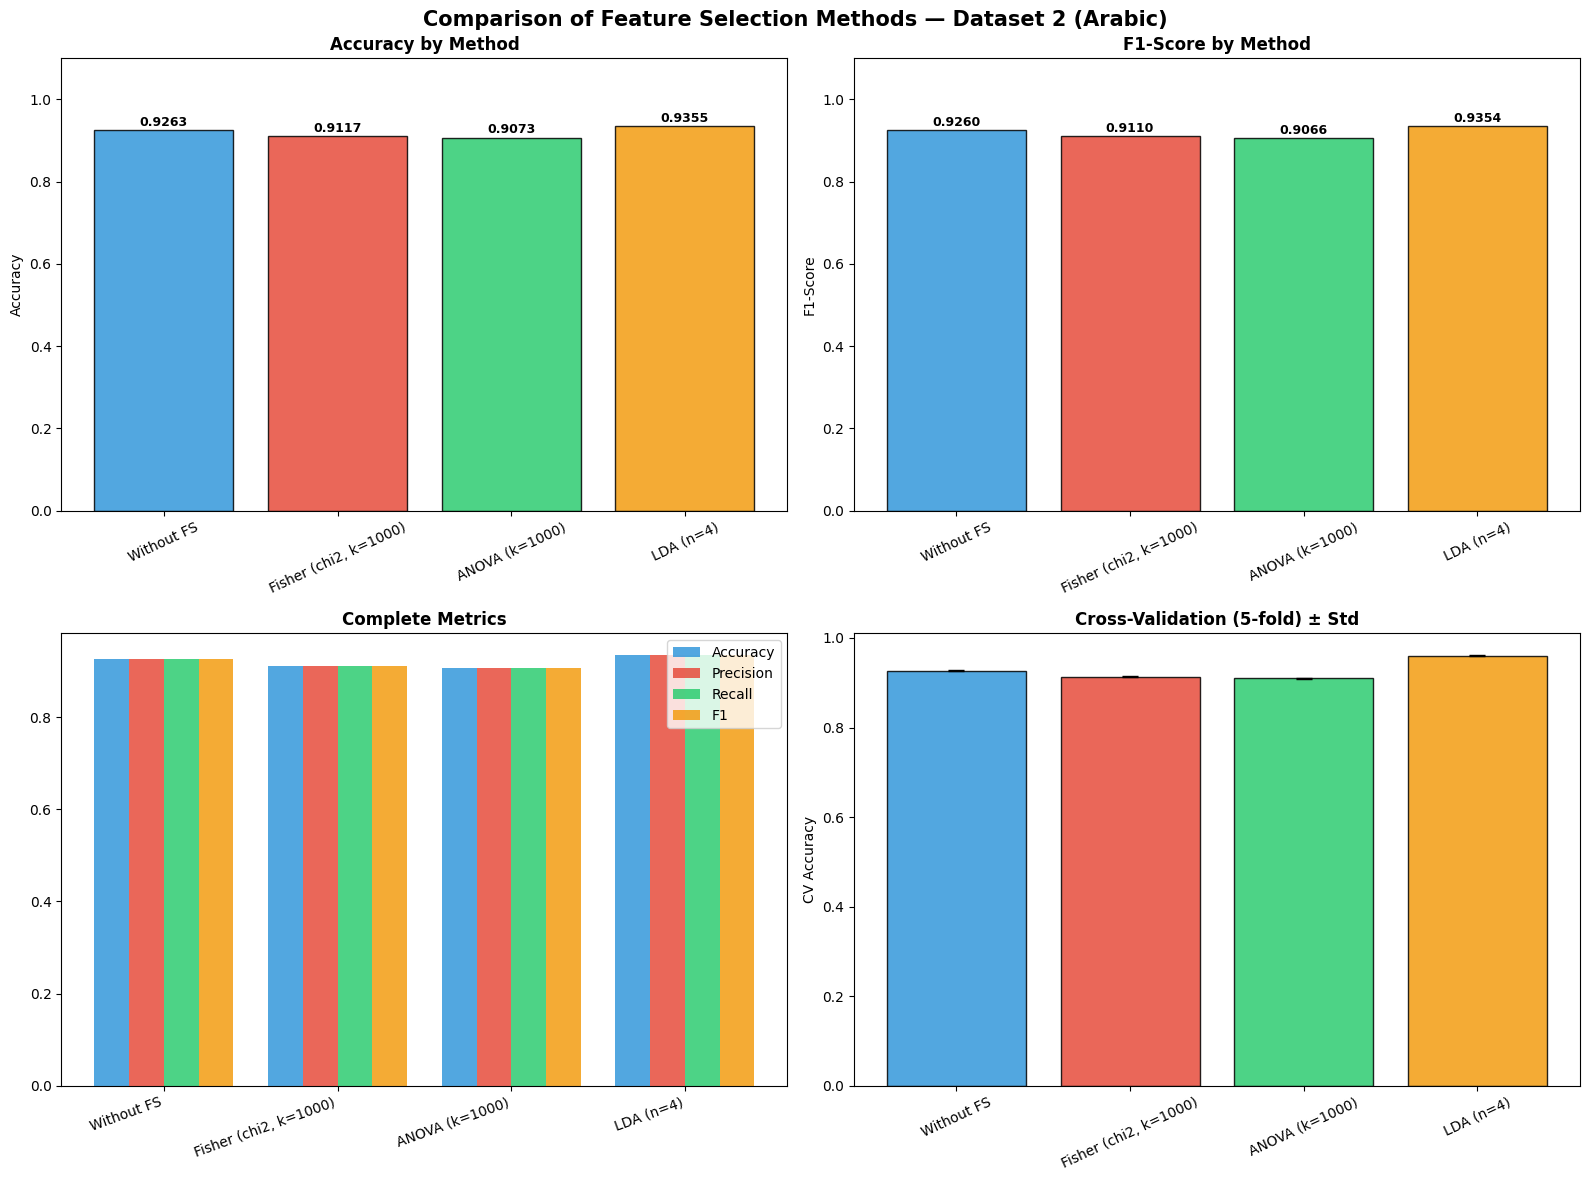

In [13]:
colors  = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']
w = 0.2
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Comparison of Feature Selection Methods — Dataset 2 (Arabic)',
             fontsize=15, fontweight='bold')

methods2 = df_results2['Method'].tolist()

axes[0,0].bar(methods2, df_results2['Accuracy'], color=colors, edgecolor='black', alpha=0.85)
axes[0,0].set_title('Accuracy by Method', fontweight='bold')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_ylim([0, 1.1])
axes[0,0].tick_params(axis='x', rotation=25)
for i, v in enumerate(df_results2['Accuracy']):
    axes[0,0].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

axes[0,1].bar(methods2, df_results2['F1-Score'], color=colors, edgecolor='black', alpha=0.85)
axes[0,1].set_title('F1-Score by Method', fontweight='bold')
axes[0,1].set_ylabel('F1-Score')
axes[0,1].set_ylim([0, 1.1])
axes[0,1].tick_params(axis='x', rotation=25)
for i, v in enumerate(df_results2['F1-Score']):
    axes[0,1].text(i, v + 0.01, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

x2 = np.arange(len(methods2))
axes[1,0].bar(x2-w,   df_results2['Accuracy'],  w, label='Accuracy',  color='#3498db', alpha=0.85)
axes[1,0].bar(x2,     df_results2['Precision'], w, label='Precision', color='#e74c3c', alpha=0.85)
axes[1,0].bar(x2+w,   df_results2['Recall'],    w, label='Recall',    color='#2ecc71', alpha=0.85)
axes[1,0].bar(x2+2*w, df_results2['F1-Score'],  w, label='F1',        color='#f39c12', alpha=0.85)

axes[1,0].set_title('Complete Metrics', fontweight='bold')
axes[1,0].set_xticks(x2 + w/2)
axes[1,0].set_xticklabels(methods2, rotation=20, ha='right')
axes[1,0].legend()

cv_means2 = df_results2['CV Mean'].values
cv_stds2  = df_results2['CV Std'].values
axes[1,1].bar(methods2, cv_means2, yerr=cv_stds2, color=colors, edgecolor='black',
              alpha=0.85, capsize=6)
axes[1,1].set_title('Cross-Validation (5-fold) ± Std', fontweight='bold')
axes[1,1].set_ylabel('CV Accuracy')
axes[1,1].tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('ds2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()